# Computer Vision 
## Bonus Notebook — Label-Efficiency Ablation (10% → 50%)

| | |
|---|---|
| **Best SSL backbone** | **DINOv3-distilled YOLOv26-s** (Notebook 4a checkpoint) — Task 1 board: I-JEPA 0.6085 / DINOv3 0.6083 (Δ0.0002 ≈ statistical tie, DINOv3 chosen for the cleaner FN profile: 4.03% vs 6.12% FN frames) / BYOL 0.6064 |
| **Supervised baseline** | COCO-pretrained `yolo26s.pt` |
| **Grid (assignment §6.1)** | 5 fractions × 2 initialisations = **10 runs**, 50 epochs each; **the two 20% runs are reused from Task 1** (4b's DINOv3 and 3b's COCO JSONs) → 8 new runs |
| **Reference line** | Part A 100%-label score on the new holdout: **0.6678** test mAP50-95 (optimistic — documented) |

**Answer these question quantitatively:** how does detection degrade as the labelled budget
shrinks 50% → 10%, and where does SSL initialisation buy the most? Outputs per §6.2:
results table, the **label-efficiency headline curve**, break-even analysis, the ρ=0.1 vs
ρ=0.5 qualitative panel, and the best-checkpoint export.

## 0. How to Run This Notebook on Kaggle — the two-commit strategy
**Budget reality (measured):** a 50-epoch fine-tune costs ~4 min per 1% of labels (80 min at
20% in 3b/4b), so the 8 new runs total ≈ 17.5 h — more than one session. Rather than cut
the assignment-standard 50 epochs, this notebook is **resumable**: every completed run
writes `bonus_runs/bonus_<init>_rho<pct>.json` + its checkpoint, already-finished runs
(local **or in any attached input**) are skipped, and a **two-level budget guard** stops launching new runs: past the 560-min soft target, or whenever `elapsed + estimated run cost` would cross the 660-min hard stop — and the estimate **self-calibrates**: after each completed run the measured minutes-per-1% replaces the prior (a deviation warning prints if the session runs >1.5x off), so a slow GPU day simply shifts more runs to Commit 2 instead of risking the wall — so no run can ever collide with Kaggle's 12 h wall; the notebook always reaches its final cell and commits cleanly. All plots render from whatever runs exist, so intermediate commits
are always valid.

1. **Create**: Kaggle → *New Notebook* → Import. **GPU T4 x2**; Internet **On**.
2. **Attach** (*Add Input*): the checkpoint dataset / **4a output**
   (`dinov3_yolo26s_backbone.pt` + `partB_partition.csv`), **Part A Notebook 1's output**
   (labels), the **committed 3b output** (COCO@20% JSON + the 100%-label reference JSON),
   and the **committed 4b output** (DINOv3@20% JSON).
3. **Commit 1** (*Save & Run All*): runs the DINOv3 arm — ρ = 10/30/40/50 — and typically also coco@10% (~10 h total); the guard then defers the remaining COCO cells and the partial plots render.
4. **Commit 2**: additionally attach **this notebook's own Commit-1 output**; the DINOv3
   JSONs are found and skipped, the COCO arm runs (~8.7 h), and every §6.2 output renders
   complete.
5. The assignment's "runs top-to-bottom without manual intervention" holds for each commit;
   the hand-off between commits is the same attached-output pattern used for the Task 1
   baselines.

## 1. CONFIG — grid, frozen protocol, budget guard
Per §2's fair-comparison rules everything is identical to Notebooks 3b/4b — only the
**backbone initialisation** and the **label fraction ρ** vary (the two permitted axes).

In [ ]:
# =============================== CONFIG ===============================

# ---- the two grid axes (the ONLY things that vary; assignment §2) ---------
FRACTIONS = [0.10, 0.20, 0.30, 0.40, 0.50]
INITS     = ["dinov3", "coco"]      # best SSL backbone vs supervised baseline
PARTB_SEED = 445                    # shared seed -> nested subsets via pool_rank

# ---- frozen fair-comparison protocol (byte-identical to 3b/4b) -------------
YOLO_ARCH    = "yolo26s.yaml"
COCO_WEIGHTS = "yolo26s.pt"
EPOCHS, PATIENCE  = 50, 25
IMGSZ, BATCH      = 640, 16
WORKERS           = 4
OPTIMIZER, LR0    = "auto", 0.01
WARMUP_EPOCHS     = 3
CLOSE_MOSAIC      = 10
FLIPLR, FLIPUD, DEGREES = 0.5, 0.0, 0.0
HSV_H, HSV_S, HSV_V     = 0.015, 0.7, 0.4
MIXUP, COPY_PASTE       = 0.0, 0.0
CONF_EVAL, IOU_NMS      = 0.25, 0.7

# ---- session management -----------------------------------------------------
SESSION_BUDGET_MIN = 560   # soft target: stop LAUNCHING new runs after ~9.3 h
EST_MIN_PER_PCT    = 4.2   # PRIOR only: ~4 min per 1% (80 min @ 20% in 3b/4b).
                           # After every completed run the guard RECALIBRATES to
                           # the measured pace automatically (see grid_run), so a
                           # slow/fast GPU day needs no manual edit -- the guard
                           # defers more or fewer runs to Commit 2 accordingly.
HARD_STOP_MIN      = 660   # a run is ALSO deferred if elapsed + its estimated
                           # cost would cross 11 h -- guarantees the session ends
                           # inside Kaggle's 12 h wall with margin for eval+plots
RUN_ORDER = [("dinov3", r) for r in (0.10, 0.30, 0.40, 0.50)] + \
            [("coco",   r) for r in (0.10, 0.30, 0.40, 0.50)]
# 20% cells come from Task 1 (4b / 3b JSONs) and are injected in Section 4.

# ---- references (Task 1 / Part A, from the committed runs) -------------------
REFERENCE_100 = 0.6678     # Part A YOLOv26-s on the new holdout (optimistic)
TASK1_WINNER  = 0.6083     # DINOv3@20% -- the tracking detector's score

# ---- inputs (manual overrides) ------------------------------------------------
CKPT_MANUAL      = None    # .../dinov3_yolo26s_backbone.pt
PARTITION_MANUAL = None    # .../partB_partition.csv
NB1_DIR_MANUAL   = None    # .../visiodect_yolo

WORK_ROOT  = "/kaggle/working"
DATA_ROOT  = f"{WORK_ROOT}/bonus_data"
RUN_PROJECT = f"{WORK_ROOT}/runs_bonus"
RUNS_DIR   = f"{WORK_ROOT}/bonus_runs"        # per-run JSONs (resume key)
CKPT_OUT   = f"{WORK_ROOT}/checkpoints"
SURGERY_CKPT = f"{WORK_ROOT}/dinov3_surgery_init.pt"

print(f"CONFIG | grid {len(FRACTIONS)}x{len(INITS)} = {len(FRACTIONS)*len(INITS)} runs "
      f"(2 reused from Task 1) | {EPOCHS} epochs each | budget guard "
      f"{SESSION_BUDGET_MIN} min | seed {PARTB_SEED}")


CONFIG | grid 5x2 = 10 runs (2 reused from Task 1) | 50 epochs each | budget guard 560 min | seed 445


## 2. Environment, Inputs, and Run Discovery (resume mechanism)
The discovery walker collects **every** `bonus_*.json` visible in the session — locally and
in any attached input — so a previous commit's runs are found and skipped. The Task-1 20%
JSONs (4b's `dinov3.json`, 3b's `coco.json`) are collected the same way.

In [2]:
%pip install -q -U ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from copy import deepcopy
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
import ultralytics

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED); torch.manual_seed(PARTB_SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 125, "font.size": 11})
for d in (DATA_ROOT, RUN_PROJECT, RUNS_DIR, CKPT_OUT):
    Path(d).mkdir(parents=True, exist_ok=True)
NOTEBOOK_T0 = time.time()
print("ultralytics:", ultralytics.__version__, "| GPU:",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def find_file(pattern, manual, what, required=True):
    if manual is not None:
        p = Path(manual); assert p.exists(), f"manual {what} missing: {p}"
        return p
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and c.name == pattern:
                    return c
                if c.is_dir() and dep < 5:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    if required:
        raise FileNotFoundError(f"{what} ({pattern}) not found — attach per Section 0.")
    return None

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL); assert (p / "train" / "images").exists(); return p
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/).")

SSL_CKPT      = find_file("dinov3_yolo26s_backbone.pt", CKPT_MANUAL, "DINOv3 checkpoint")
PARTITION_CSV = find_file("partB_partition.csv", PARTITION_MANUAL, "partition manifest")
NB1_ROOT      = find_nb1_root()
print("DINOv3 ckpt :", SSL_CKPT)
print("partition   :", PARTITION_CSV)
print("NB1 labels  :", NB1_ROOT)

# ---- collect finished runs: local + attached (resume) + Task-1 20% JSONs ------
def collect_run_records():
    recs = {}
    def take(path):
        try:
            r = json.loads(path.read_text())
        except Exception:
            return
        if "rho" in r and "init" in r and "test_mAP50_95" in r:
            key = (r["init"], round(float(r["rho"]), 2))
            recs.setdefault(key, r)
    for p in Path(RUNS_DIR).glob("bonus_*.json"):
        take(p)
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and c.suffix == ".json" and (
                        c.name.startswith("bonus_") or
                        (c.parent.name == "partB_downstream" and
                         c.stem in ("dinov3", "coco"))):
                    take(c)
                elif c.is_dir() and dep < 6:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    return recs

records = collect_run_records()
print(f"runs already available: {sorted(records)}  "
      "(Task-1 20% cells + any previous commit)")

def resolve_ckpt(rec):
    """Checkpoint paths from attached JSONs point at a PREVIOUS session's
    /kaggle/working -- resolve by basename across this session + all inputs."""
    if not rec.get("checkpoint"):
        return None
    p = Path(rec["checkpoint"])
    if p.exists():
        return p
    name = p.name
    local = Path(CKPT_OUT) / name
    if local.exists():
        return local
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and c.name == name:
                    return c
                if c.is_dir() and dep < 6:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    return None


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.120 | GPU: Tesla T4
DINOv3 ckpt : /kaggle/input/notebooks/ahnafahmed11/partb-notebook4a-dinov3-self-supervisedpretraining/dinov3_yolo26s_backbone.pt
partition   : /kaggle/input/notebooks/ahnafahmed11/partb-notebook4a-dinov3-self-supervisedpretraining/partB_partition.csv
NB1 labels  : /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
runs already available: [('coco', 0.1), ('coco', 0.2), ('dinov3', 0.1), ('dinov3', 0.2), ('dinov3', 0.3), ('dinov3', 0.4), ('dinov3', 0.5)]  (Task-1 20% cells + any previous commit)


## 3. Nested, Seeded Label Budgets — D₀.₁ ⊂ D₀.₂ ⊂ ⋯ ⊂ D₀.₅ 
The shared manifest's `pool_rank` (assigned once in Notebook 3a by the seeded shuffle) makes
nesting **structural**: budget ρ is simply `pool_rank < round(ρ·N)`, so each larger budget
strictly adds images. The cell prints the sizes and **asserts the subset chain** — the exact
property viva Q1 asks about (independently sampled fractions would confound the curve:
composition changes, not just quantity, between points).

In [4]:
partition = pd.read_csv(PARTITION_CSV)
N = len(partition)
pool = partition[partition.partition == "ssl_pool"]
budgets = {r: set(pool[pool.pool_rank < round(r * N)].filename) for r in FRACTIONS}

sizes = {f"{int(r*100)}%": len(budgets[r]) for r in FRACTIONS}
print("budget sizes:", sizes, f"(N = {N:,})")
fr = sorted(FRACTIONS)
for a, b in zip(fr, fr[1:]):
    assert budgets[a] < budgets[b], f"nesting violated: {a} not subset of {b}"
print("[OK] nesting verified: " +
      " ⊂ ".join(f"D{r:0.1f}".replace("0.", "0.") for r in fr) +
      f"  (each larger budget strictly adds images; seed {PARTB_SEED})")

va, te = (set(partition[partition.partition == k].filename) for k in ("val", "test"))
assert not (budgets[max(fr)] & va) and not (budgets[max(fr)] & te)
print("[OK] disjointness: even the 50% budget shares zero files with val/test")

CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]
label_for = lambda img: Path(str(img).replace("/images/", "/labels/")).with_suffix(".txt")

def safe_link(src, dst):
    if not dst.exists():
        try:
            os.symlink(src, dst)
        except OSError:
            shutil.copy2(src, dst)

data_root = Path(DATA_ROOT)
src_of = dict(zip(partition.filename, partition.source_path))
for split, names in [("val", va), ("test", te)]:
    (data_root / split / "images").mkdir(parents=True, exist_ok=True)
    (data_root / split / "labels").mkdir(parents=True, exist_ok=True)
    for n in names:
        img = Path(src_of[n])
        safe_link(img, data_root / split / "images" / n)
        safe_link(label_for(img), data_root / split / "labels" / label_for(img).name)

YAMLS = {}
for r in FRACTIONS:
    tag = f"rho{int(r*100)}"
    (data_root / tag / "images").mkdir(parents=True, exist_ok=True)
    (data_root / tag / "labels").mkdir(parents=True, exist_ok=True)
    for n in budgets[r]:
        img = Path(src_of[n])
        safe_link(img, data_root / tag / "images" / n)
        safe_link(label_for(img), data_root / tag / "labels" / label_for(img).name)
    y = data_root / f"data_{tag}.yaml"
    y.write_text(f"path: {data_root}\ntrain: {tag}/images\nval: val/images\n"
                 f"test: test/images\nnc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
    YAMLS[r] = y
print("materialised:", {f"{int(r*100)}%": len(budgets[r]) for r in FRACTIONS},
      "+ shared val/test")


budget sizes: {'10%': 2060, '20%': 4121, '30%': 6181, '40%': 8241, '50%': 10302} (N = 20,603)
[OK] nesting verified: D0.1 ⊂ D0.2 ⊂ D0.3 ⊂ D0.4 ⊂ D0.5  (each larger budget strictly adds images; seed 445)
[OK] disjointness: even the 50% budget shares zero files with val/test
materialised: {'10%': 2060, '20%': 4121, '30%': 6181, '40%': 8241, '50%': 10302} + shared val/test


## 4. Weight Surgery for the DINOv3 Arm 
Backbone modules `model[: len(yaml['backbone'])]` from the 4a checkpoint into a fresh
YOLOv26-s (new random neck/head), with the checksum proofs. The COCO arm needs no surgery —
`yolo26s.pt` is its own initialisation.

In [5]:
ssl_yolo, fresh = YOLO(str(SSL_CKPT)), YOLO(YOLO_ARCH)
BACKBONE_END = len(fresh.model.yaml["backbone"])
ssl_sd, fresh_sd = ssl_yolo.model.state_dict(), fresh.model.state_dict()
assert set(ssl_sd) == set(fresh_sd)
merged, moved = {}, 0
for k, v in fresh_sd.items():
    idx = int(k.split(".")[1]) if k.startswith("model.") else -1
    take = 0 <= idx < BACKBONE_END
    merged[k] = ssl_sd[k].clone() if take else v
    moved += v.numel() * take
fresh.model.load_state_dict(merged, strict=True)
torch.save({"model": deepcopy(fresh.model), "train_args": {}}, SURGERY_CKPT)
re_sd = YOLO(SURGERY_CKPT).model.state_dict()
bb = next(k for k in ssl_sd if k.startswith("model.0.") and ssl_sd[k].ndim > 1)
hd = next(k for k in fresh_sd
          if k.startswith(f"model.{len(fresh.model.model)-1}.") and fresh_sd[k].ndim > 1)
print(f"surgery: modules 0..{BACKBONE_END-1} <- DINOv3 "
      f"({moved/1e6:.2f} M of {sum(v.numel() for v in fresh_sd.values())/1e6:.2f} M params); "
      f"proofs: backbone==SSL {torch.equal(re_sd[bb].float(), ssl_sd[bb].float())}, "
      f"head==fresh {torch.equal(re_sd[hd].float(), fresh_sd[hd].float())}")
del ssl_yolo, fresh, merged, ssl_sd, fresh_sd, re_sd
torch.cuda.empty_cache()


surgery: modules 0..10 <- DINOv3 (5.46 M of 10.05 M params); proofs: backbone==SSL True, head==fresh True


## 5. The Grid Runner — resumable, budget-guarded 
Skips any (init, ρ) whose JSON already exists (Task-1 20% cells, or a previous commit's
attached output), otherwise trains 50 epochs under the frozen protocol, evaluates on the
fixed test holdout, and writes `bonus_<init>_rho<pct>.json` + the checkpoint. The budget
guard stops **launching** new runs near the session limit — finished work is never lost.

In [6]:
MEASURED_RATES = []                 # min per 1% of labels, one entry per run
def current_rate():
    """Live pace estimate: measured mean once any run finished, else the prior."""
    return float(np.mean(MEASURED_RATES)) if MEASURED_RATES else EST_MIN_PER_PCT

def grid_run(init_name, rho):
    key = (init_name, round(rho, 2))
    if key in records:
        src = "Task 1" if records[key].get("reused_from_task1") or \
              abs(rho - 0.20) < 1e-9 else "previous commit"
        print(f"skip {init_name}@{int(rho*100)}% — already available ({src})")
        return
    elapsed = (time.time() - NOTEBOOK_T0) / 60
    est = current_rate() * 1.15 * rho * 100 + 10    # live pace + 15% safety + eval
    if elapsed > SESSION_BUDGET_MIN or elapsed + est > HARD_STOP_MIN:
        reason = (f"{elapsed:.0f} min elapsed > soft target {SESSION_BUDGET_MIN}"
                  if elapsed > SESSION_BUDGET_MIN else
                  f"{elapsed:.0f} + est {est:.0f} min would cross the "
                  f"{HARD_STOP_MIN}-min hard stop")
        print(f"BUDGET GUARD ({reason}): {init_name}@{int(rho*100)}% deferred to the "
              "next commit (attach this output and rerun).")
        return
    tag = f"{init_name}_rho{int(rho*100)}"
    weights = SURGERY_CKPT if init_name == "dinov3" else COCO_WEIGHTS
    print(f"=== {tag}: {len(budgets[rho]):,} train images, {EPOCHS} epochs "
          f"(elapsed {elapsed:.0f} min) ===")
    t0 = time.time()
    model = YOLO(weights)
    model.train(data=str(YAMLS[rho]), epochs=EPOCHS, patience=PATIENCE, imgsz=IMGSZ,
                batch=BATCH, workers=WORKERS, device=DEVICE, seed=PARTB_SEED,
                project=RUN_PROJECT, name=tag, exist_ok=True,
                optimizer=OPTIMIZER, lr0=LR0, warmup_epochs=WARMUP_EPOCHS,
                close_mosaic=CLOSE_MOSAIC, fliplr=FLIPLR, flipud=FLIPUD, degrees=DEGREES,
                hsv_h=HSV_H, hsv_s=HSV_S, hsv_v=HSV_V, mixup=MIXUP, copy_paste=COPY_PASTE,
                plots=False, verbose=False)
    minutes = (time.time() - t0) / 60
    run_dir = Path(RUN_PROJECT) / tag
    best = run_dir / "weights" / "best.pt"
    best = best if best.exists() else run_dir / "weights" / "last.pt"
    ckpt_out = Path(CKPT_OUT) / f"bonus_{tag}_best.pt"
    shutil.copy2(best, ckpt_out)
    model = YOLO(str(best))
    rec = {"init": init_name, "rho": rho, "epochs": EPOCHS,
           "train_images": len(budgets[rho]), "train_minutes": round(minutes, 1),
           "checkpoint": str(ckpt_out)}
    m = model.val(data=str(YAMLS[rho]), split="test", imgsz=IMGSZ, batch=BATCH,
                  conf=0.001, iou=IOU_NMS, device=DEVICE, plots=False,
                  project=f"{WORK_ROOT}/evaluation", name=f"{tag}_test",
                  exist_ok=True, verbose=False)
    rec |= {"test_precision": round(float(m.box.mp), 4),
            "test_recall": round(float(m.box.mr), 4),
            "test_mAP50": round(float(m.box.map50), 4),
            "test_mAP50_95": round(float(m.box.map), 4)}
    Path(RUNS_DIR, f"bonus_{tag}.json").write_text(json.dumps(rec, indent=2))
    records[key] = rec
    rate = minutes / (rho * 100)
    prev = current_rate()
    MEASURED_RATES.append(rate)
    print(f"[{tag}] {minutes:.0f} min | test mAP50-95 {rec['test_mAP50_95']}")
    print(f"    pace recalibrated: {rate:.2f} min per 1% measured "
          f"(guard was assuming {prev:.2f}; live estimate now {current_rate():.2f})")
    if not (0.5 <= rate / EST_MIN_PER_PCT <= 1.5) and len(MEASURED_RATES) == 1:
        print(f"    [!] PACE DEVIATION: this session runs at {rate:.2f} min/1% vs the "
              f"{EST_MIN_PER_PCT} prior ({rate/EST_MIN_PER_PCT:.1f}x). No action needed "
              "-- the guard now plans with the measured pace and will defer any run "
              "that cannot finish before the hard stop; deferred cells resume in the "
              "next commit. (Optionally update EST_MIN_PER_PCT to "
              f"{rate:.1f} for future sessions.)")
    torch.cuda.empty_cache()

for init_name, rho in RUN_ORDER:
    grid_run(init_name, rho)
done = sorted(records)
missing = [(i, r) for i in INITS for r in FRACTIONS if (i, round(r, 2)) not in records]
print(f"\ngrid status: {len(done)}/10 cells done."
      + ("" if not missing else f" Missing {missing} — attach this commit's output "
                                "and rerun (Section 0, Commit 2)."))


skip dinov3@10% — already available (previous commit)
skip dinov3@30% — already available (previous commit)
skip dinov3@40% — already available (previous commit)
skip dinov3@50% — already available (previous commit)
skip coco@10% — already available (previous commit)
=== coco_rho30: 6,181 train images, 50 epochs (elapsed 2 min) ===
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bonus_data/data_rho30.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exis

## 6. Results Table 

In [7]:
table = pd.DataFrame([records[k] for k in sorted(records)])
cols = [c for c in ["init", "rho", "train_images", "test_precision", "test_recall",
                    "test_mAP50", "test_mAP50_95", "train_minutes"] if c in table]
table = table[cols].sort_values(["init", "rho"]).reset_index(drop=True)
display(table)
table.to_csv(f"{WORK_ROOT}/bonus_results_table.csv", index=False)


,init,rho,train_images,test_precision,test_recall,test_mAP50,test_mAP50_95,train_minutes
0,coco,0.1,2060.0,0.9704,0.9710,0.9778,0.6066,45.7
1,coco,0.2,NaN,0.9698,0.9731,0.9839,0.6224,80.2
2,coco,0.3,6181.0,0.9774,0.9783,0.9874,0.6344,113.3
3,coco,0.4,8241.0,0.9811,0.9796,0.9899,0.6432,146.5
4,coco,0.5,10302.0,0.9782,0.9821,0.9889,0.6456,180.7
5,dinov3,0.1,2060.0,0.9294,0.9132,0.9616,0.5876,46.3
6,dinov3,0.2,NaN,0.9525,0.9411,0.9760,0.6083,84.1
7,dinov3,0.3,6181.0,0.9603,0.9612,0.9830,0.6254,114.4
8,dinov3,0.4,8241.0,0.9641,0.9684,0.9855,0.6326,149.9
9,dinov3,0.5,10302.0,0.9775,0.9768,0.9893,0.6339,185.4


## 7. The Headline Figure — Label-Efficiency Curve 
Test mAP50-95 vs label fraction, one line per initialisation, the Part A 100%-label score as
the dashed reference. Renders from whatever grid cells exist, so it is valid on every
commit.

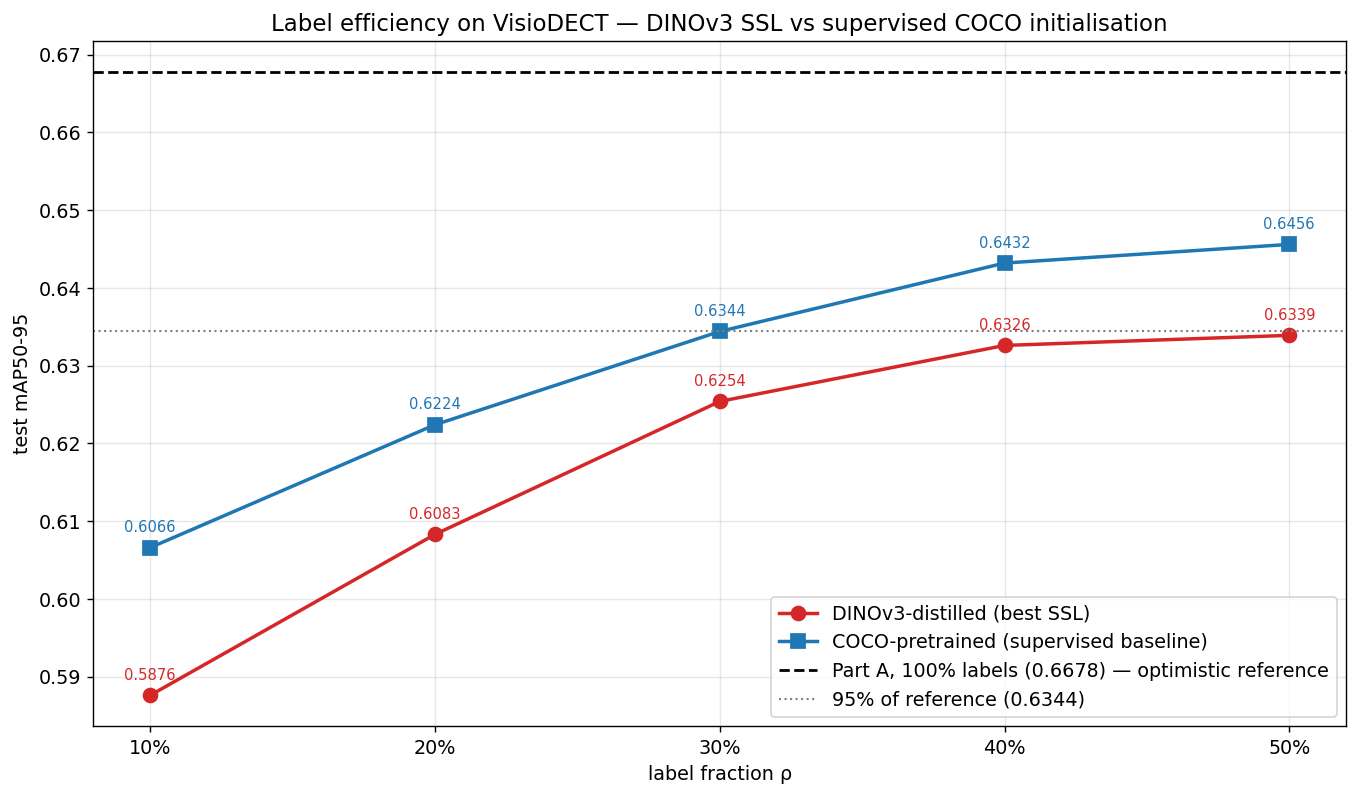

In [8]:
fig, ax = plt.subplots(figsize=(11, 6.5))
STYLE = {"dinov3": ("tab:red", "o", "DINOv3-distilled (best SSL)"),
         "coco":   ("tab:blue", "s", "COCO-pretrained (supervised baseline)")}
for init_name, (col, mk, label) in STYLE.items():
    pts = sorted((r["rho"], r["test_mAP50_95"]) for (i, _), r in records.items()
                 if i == init_name)
    if pts:
        xs, ys = zip(*pts)
        ax.plot(xs, ys, color=col, marker=mk, ms=8, lw=2, label=label)
        for x, y in pts:
            ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                        xytext=(0, 9), ha="center", fontsize=8.5, color=col)
ax.axhline(REFERENCE_100, color="black", ls="--", lw=1.6,
           label=f"Part A, 100% labels ({REFERENCE_100}) — optimistic reference")
ax.axhline(0.95 * REFERENCE_100, color="grey", ls=":", lw=1.2,
           label=f"95% of reference ({0.95*REFERENCE_100:.4f})")
ax.set_xlabel("label fraction ρ"); ax.set_ylabel("test mAP50-95")
ax.set_xticks(FRACTIONS, [f"{int(r*100)}%" for r in FRACTIONS])
ax.set_title("Label efficiency on VisioDECT — DINOv3 SSL vs supervised COCO initialisation")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/label_efficiency_curve.png", dpi=160, bbox_inches="tight")
plt.show()


## 8. Break-Even Analysis 
The two mandated thresholds: the smallest ρ at which the SSL-initialised detector matches or
exceeds **(a)** the supervised baseline at 50%, and **(b)** 95% of the Part A full-label
reference — each translated into an annotation-cost statement for the report.

In [9]:
get = lambda i, r: records.get((i, round(r, 2)), {}).get("test_mAP50_95")
coco50 = get("coco", 0.50)
target_b = 0.95 * REFERENCE_100

def break_even(target, name):
    if target is None:
        print(f"(a/b) target for '{name}' not yet available — rerun after Commit 2")
        return None
    for r in sorted(FRACTIONS):
        v = get("dinov3", r)
        if v is not None and v >= target:
            print(f"break-even vs {name}: rho = {int(r*100)}%  "
                  f"(DINOv3 {v:.4f} >= {target:.4f})")
            return r
    have = [f"{int(r*100)}%:{get('dinov3', r)}" for r in FRACTIONS
            if get("dinov3", r) is not None]
    print(f"no break-even vs {name} within 10–50%  (DINOv3 curve: {have}; "
          f"target {target:.4f}) — itself a reportable finding")
    return None

be_a = break_even(coco50, "supervised COCO @ 50% labels")
be_b = break_even(target_b, "95% of the Part A reference")
if be_a:
    print(f"-> annotation-cost statement (a): SSL pretraining lets {int(be_a*100)}% of the "
          f"boxes do the work of the supervised pipeline's 50% — a "
          f"{(0.50-be_a)/0.50:.0%} labelling-cost reduction at equal accuracy.")
if be_b:
    print(f"-> annotation-cost statement (b): {int(be_b*100)}% of labels already recovers "
          "95% of the full-label reference.")


no break-even vs supervised COCO @ 50% labels within 10–50%  (DINOv3 curve: ['10%:0.5876', '20%:0.6083', '30%:0.6254', '40%:0.6326', '50%:0.6339']; target 0.6456) — itself a reportable finding
no break-even vs 95% of the Part A reference within 10–50%  (DINOv3 curve: ['10%:0.5876', '20%:0.6083', '30%:0.6254', '40%:0.6326', '50%:0.6339']; target 0.6344) — itself a reportable finding


## 9. Qualitative Panel — the Same 3 Test Images at ρ = 0.1 vs ρ = 0.5 
Seeded image choice (one per scenario where possible), DINOv3 arm, GT in green, predictions
in red — the visual counterpart of the curve: what an extra 40% of labels actually buys.

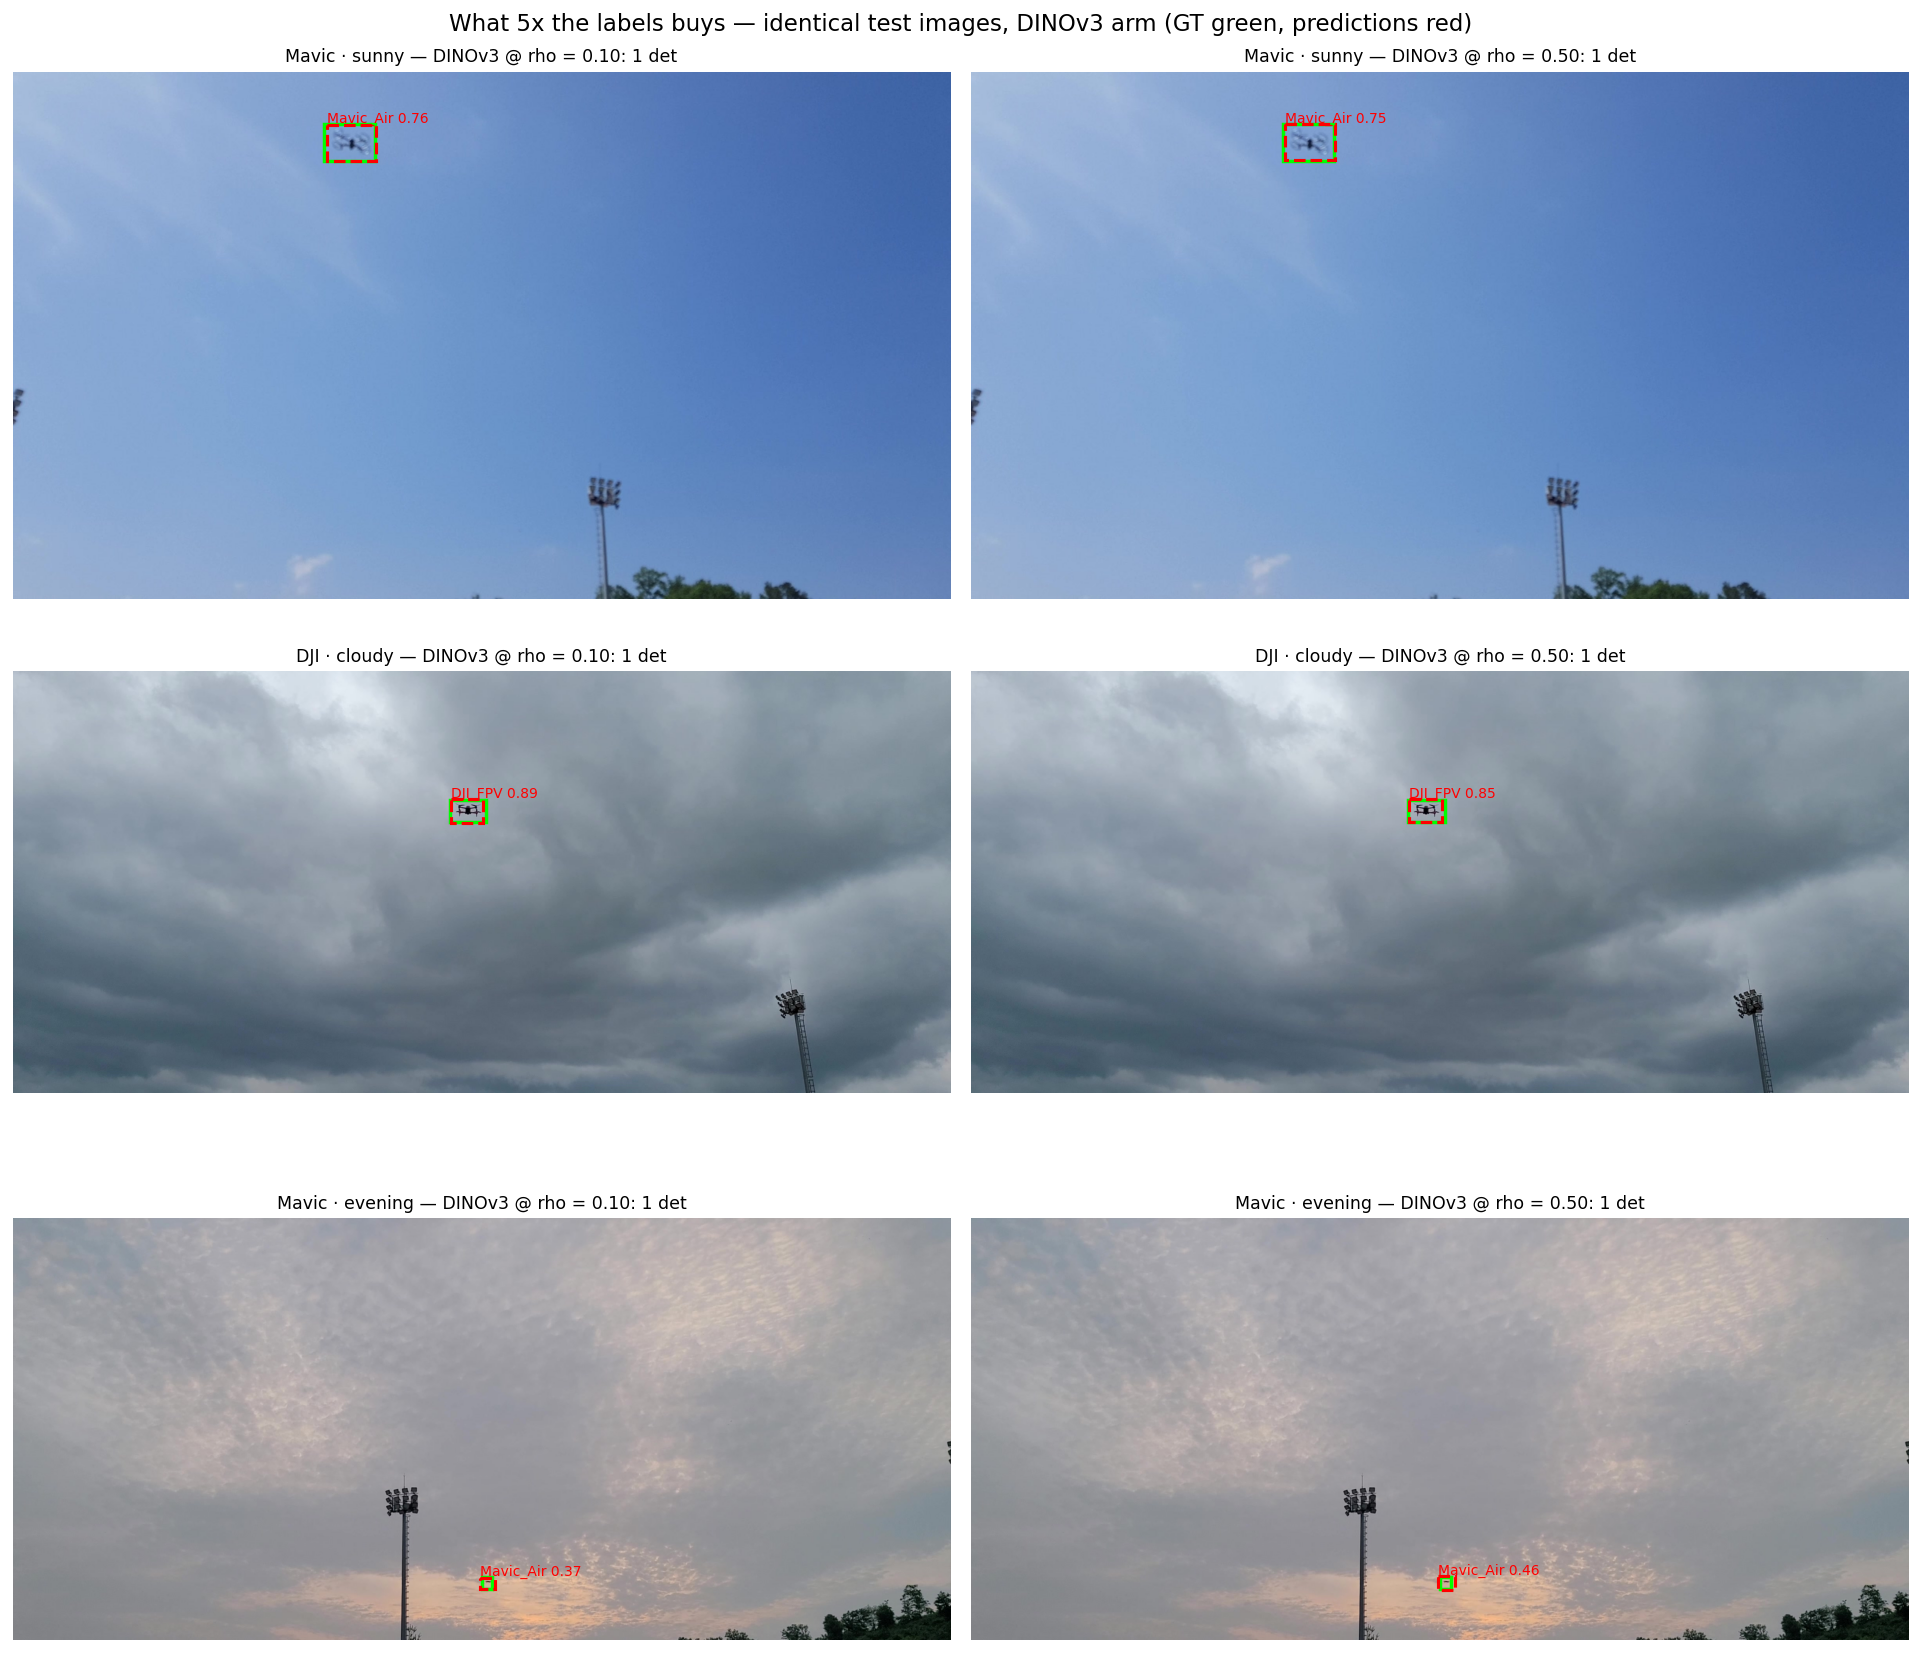

In [10]:
def parse_scen(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            return stem[len(c)+1:].split("_")[0]
    return "unknown"

ck10 = resolve_ckpt(records.get(("dinov3", 0.10), {}))
ck50 = resolve_ckpt(records.get(("dinov3", 0.50), {}))
if ck10 and ck50:
    test_imgs = sorted((Path(DATA_ROOT) / "test" / "images").iterdir())
    rng = random.Random(PARTB_SEED)
    picks, seen = [], set()
    for p in rng.sample(test_imgs, len(test_imgs)):
        s = parse_scen(p.stem)
        if s not in seen:
            picks.append(p); seen.add(s)
        if len(picks) == 3:
            break
    picks = picks or test_imgs[:3]
    models = {"rho = 0.10": YOLO(str(ck10)), "rho = 0.50": YOLO(str(ck50))}
    fig, axes = plt.subplots(3, 2, figsize=(15.5, 14))
    for row, img in enumerate(picks):
        with Image.open(img) as im0:
            arr = np.array(im0.convert("RGB")); H, W = arr.shape[:2]
        gts = []
        for ln in label_for(img).read_text().splitlines():
            t = ln.split()
            if len(t) == 5:
                _, cx, cy, w, h = map(float, t)
                gts.append(((cx-w/2)*W, (cy-h/2)*H, w*W, h*H))
        for col, (name, mdl) in enumerate(models.items()):
            ax = axes[row, col]; ax.imshow(arr); ax.set_axis_off()
            for x, y, w, h in gts:
                ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                                edgecolor="lime", lw=2))
            r = mdl.predict(str(img), imgsz=IMGSZ, conf=CONF_EVAL, iou=IOU_NMS,
                            device=DEVICE, verbose=False)[0]
            n = 0
            if r.boxes is not None:
                for b, ci, cf in zip(r.boxes.xyxy.cpu().numpy(),
                                     r.boxes.cls.cpu().numpy().astype(int),
                                     r.boxes.conf.cpu().numpy()):
                    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                                    fill=False, edgecolor="red",
                                                    lw=1.8, linestyle="--"))
                    ax.text(b[0], b[1]-6, f"{CLASS_NAMES[ci]} {cf:.2f}",
                            color="red", fontsize=8)
                    n += 1
            ax.set_title(f"{img.stem.split('_')[0]} · {parse_scen(img.stem)} — "
                         f"DINOv3 @ {name}: {n} det", fontsize=10)
    fig.suptitle("What 5x the labels buys — identical test images, DINOv3 arm "
                 "(GT green, predictions red)")
    plt.tight_layout()
    plt.savefig(f"{WORK_ROOT}/qualitative_rho10_vs_rho50.png", dpi=150,
                bbox_inches="tight")
    plt.show()
else:
    print("qualitative panel needs the dinov3 10% and 50% checkpoints — attach the "
          "commit that trained them (their .pt files resolve by name across inputs).")


## 10. Best-Checkpoint Export 

In [11]:
resolved = {k: (r, resolve_ckpt(r)) for k, r in records.items()}
have_ckpt = {k: (r, p) for k, (r, p) in resolved.items() if p is not None}
missing_ck = [k for k, (r, p) in resolved.items() if r.get("checkpoint") and p is None]
if missing_ck:
    print("note: no .pt found for", missing_ck,
          "(Task-1 JSONs carry no bonus checkpoints -- expected)")
if have_ckpt:
    best_key = max(have_ckpt, key=lambda k: have_ckpt[k][0]["test_mAP50_95"])
    best, best_path = have_ckpt[best_key]
    out = Path(WORK_ROOT) / "bonus_best_overall.pt"
    shutil.copy2(best_path, out)
    print(f"best across grid: {best_key[0]}@{int(best_key[1]*100)}% -> "
          f"test mAP50-95 {best['test_mAP50_95']} | exported {out.name} "
          f"({out.stat().st_size/1e6:.1f} MB)")
    print("publish it to the checkpoint dataset;",
          f"Task-1 winner was {TASK1_WINNER} —",
          "it outperforms the tracking detector, so per §6.2 you MAY rerun Notebook 5 "
          "with it and report both results."
          if best["test_mAP50_95"] > TASK1_WINNER else
          "it does not beat the Task-1 winner, so the tracking notebook stands as-is.")
else:
    print("no locally trained checkpoints in this session (all cells reused) — "
          "export happens on the commit that trains the winning cell.")
summary = {"grid": {f"{k[0]}@{int(k[1]*100)}%": r.get("test_mAP50_95")
                    for k, r in sorted(records.items())},
           "reference_100pct": REFERENCE_100, "task1_winner": TASK1_WINNER}
Path(WORK_ROOT, "bonus_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))


best across grid: coco@50% -> test mAP50-95 0.6456 | exported bonus_best_overall.pt (20.3 MB)
publish it to the checkpoint dataset; Task-1 winner was 0.6083 — it outperforms the tracking detector, so per §6.2 you MAY rerun Notebook 5 with it and report both results.
{
  "grid": {
    "coco@10%": 0.6066,
    "coco@20%": 0.6224,
    "coco@30%": 0.6344,
    "coco@40%": 0.6432,
    "coco@50%": 0.6456,
    "dinov3@10%": 0.5876,
    "dinov3@20%": 0.6083,
    "dinov3@30%": 0.6254,
    "dinov3@40%": 0.6326,
    "dinov3@50%": 0.6339
  },
  "reference_100pct": 0.6678,
  "task1_winner": 0.6083
}


## 11. Pre-Commit Checklist 
- [ ] Nesting assertion `[OK]` printed (D₀.₁ ⊂ ⋯ ⊂ D₀.₅) + disjointness vs val/test
- [ ] Grid status line shows which cells ran / were reused / are deferred
- [ ] Results table + **label-efficiency curve** + break-even statements rendered
- [ ] Qualitative ρ=0.1 vs ρ=0.5 panel rendered (final commit)
- [ ] `bonus_best_overall.pt` exported and published; tracking-rerun decision recorded
- [ ] Commit 2 attached Commit 1's output; all 10 cells present in the final version
